In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

In [2]:
!pip install polars

import polars as pl

In [3]:
def plot_histogram(df, column, bins=50, title=None, xlabel=None, ylabel="Frequency", yscale ='linear'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    plt.figure()
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(title or f"Histogram of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.grid(True)
    plt.show()

def plot_histogram_by_type(df, value_column, type_column="type", bins=50, alpha=0.7, filename = 'default_file', title = None):
    if value_column not in df.columns or type_column not in df.columns:
        raise ValueError(f"Columns '{value_column}' and/or '{type_column}' not found in DataFrame.")

    # Compute shared bin edges from entire column
    data = df[value_column].dropna()
    bin_edges = np.linspace(data.min(), data.max(), bins + 1)

    plt.figure(figsize=(8, 6))

    for t in df[type_column].unique():
        subset = df[df[type_column] == t][value_column].dropna()
        plt.hist(subset, bins=bin_edges, alpha=alpha, label=t, edgecolor='black', histtype='stepfilled')

    plt.xlabel(value_column)
    plt.ylabel("Frequency")
    plt.yscale('log')
    title = title or f"Histogram of {value_column} by {type_column} from {filename}"
    plt.title(title)
    plt.legend(title=type_column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Physics Helper Functions (from original script) ---

def delta_phi(phi1, phi2):
    """Computes the difference in phi, handling the wrap-around at pi."""
    # Ensure inputs are numpy arrays for broadcasting
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def delta_r(eta1, eta2, phi1, phi2):
    """Computes the delta R distance between two objects."""
    deta = np.asarray(eta1) - np.asarray(eta2)
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)



In [4]:
# --- Configuration ---
DATA_DIR = 'data_filtered'

In [5]:

# --- Mass Constants in MeV ---
M_ELECTRON = 0.511
M_MUON = 105.66
M_PION = 139.57   # Charged Pion
M_KAON = 493.68   # Charged Kaon
M_PROTON = 938.27 # Proton

# Tolerances (MeV) - slightly relaxed to account for reconstruction variations
TOL_ZERO = 0.1
TOL_E = 0.1
TOL_MU = 2.0
TOL_HADRON = 5.0 # Wider tolerance for hadrons

In [6]:
# --- Helper Functions ---
def delta_phi(phi1, phi2):
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def get_pid_one_hot(mass_col):
    """
    Encodes mass (MeV) into One-Hot PID.
    Categories: 
    0: Zero Mass (Photon/Neutral)
    1: Electron
    2: Pion (Charged)
    3: Kaon (Charged)
    4: Proton
    5: Other (No Match)
    """
    m = mass_col.values
    abs_m = np.abs(m)
    
    # Default to 5 (Other)
    pids = np.full(m.shape, 5, dtype=int)
    
    # Check matches
    # 0: Zero/Photon
    pids[abs_m < TOL_ZERO] = 0
    
    # 1: Electron
    pids[np.abs(abs_m - M_ELECTRON) < TOL_E] = 1
    
    # 2: Pion
    pids[np.abs(abs_m - M_PION) < TOL_HADRON] = 2
    
    # 3: Kaon
    pids[np.abs(abs_m - M_KAON) < TOL_HADRON] = 3
    
    # 4: Proton
    pids[np.abs(abs_m - M_PROTON) < TOL_HADRON] = 4
    
    # One Hot Encode (6 classes)
    n_classes = 6
    one_hot = np.eye(n_classes)[pids]
    return one_hot

In [7]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import polars as pl
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. Configuration
# ==========================================
DATA_DIR = "data_filtered"  # Adjust if needed
MODEL_PATH = "gnn_only_best_model.pth"
OUTPUT_DIR = "gnn_score"
BATCH_SIZE = 4096
MAX_CONSTITUENTS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [15]:
# --- Model Definition (Interaction Network) ---
def create_interaction_matrices(n_particles):
    # Receiver Matrix (RR) [N, N(N-1)]
    RR = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    # Sender Matrix (RS) [N, N(N-1)]
    RS = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    
    cnt = 0
    for i in range(n_particles):
        for j in range(n_particles):
            if i != j:
                RR[i, cnt] = 1.0
                RS[j, cnt] = 1.0
                cnt += 1
    return torch.tensor(RR), torch.tensor(RS)

class InteractionNetwork(nn.Module):
    def __init__(self, n_particles, n_features, output_dim=1):
        super(InteractionNetwork, self).__init__()
        
        # Interaction Matrices
        RR, RS = create_interaction_matrices(n_particles)
        self.register_buffer('RR', RR)
        self.register_buffer('RS', RS)
        
        # --- Relational Model (Edge Function) ---
        # Input: 2 * n_features
        # Architecture: 80 -> 50 -> 30 -> BN
        # We use Linear layers. Since they process (Batch, N_edges, Feats), 
        # BatchNorm1d requires (Batch, Feats, N_edges). We handle permutation in forward.
        self.rel_layer1 = nn.Sequential(nn.Linear(2 * n_features, 80), nn.ReLU())
        self.rel_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.rel_layer3 = nn.Sequential(nn.Linear(50, 30), nn.ReLU())
        self.rel_bn = nn.BatchNorm1d(30)
        
        # --- Object Model (Node Function) ---
        # Input: n_features + 30 (aggregated effect)
        # Architecture: 80 -> 50 -> 24
        self.obj_layer1 = nn.Sequential(nn.Linear(n_features + 30, 80), nn.ReLU())
        self.obj_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.obj_layer3 = nn.Sequential(nn.Linear(50, 24), nn.ReLU())
        
        # --- Classifier (Global) ---
        # Input: 24 (Summed over particles)
        # Architecture: 60 -> BN -> 30 -> 10 -> 1
        self.cls_layer1 = nn.Sequential(nn.Linear(24, 60), nn.ReLU())
        self.cls_bn = nn.BatchNorm1d(60)
        self.cls_layer2 = nn.Sequential(nn.Linear(60, 30), nn.ReLU())
        self.cls_layer3 = nn.Sequential(nn.Linear(30, 10), nn.ReLU())
        self.cls_out = nn.Linear(10, output_dim) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (Batch, N_particles, Features)
        
        # 1. Create Edge Features
        x_transpose = x.transpose(1, 2) # (B, F, N)
        receivers = torch.matmul(x_transpose, self.RR)
        senders = torch.matmul(x_transpose, self.RS)
        edges = torch.cat([receivers, senders], dim=1)
        edges = edges.transpose(1, 2) # (B, N_edges, 2*F)
        
        # 2. Relational Model
        e = self.rel_layer1(edges)
        e = self.rel_layer2(e)
        e = self.rel_layer3(e)
        
        # Apply BN to edges (B, N_edges, 30) -> Permute -> BN -> Permute
        e = e.transpose(1, 2) # (B, 30, N_edges)
        e = self.rel_bn(e)
        e = e.transpose(1, 2) # (B, N_edges, 30)
        
        # 3. Aggregate
        effect_agg = torch.matmul(e.transpose(1, 2), self.RR.t())
        effect_agg = effect_agg.transpose(1, 2) # (B, N, 30)
        
        # 4. Object Model
        node_input = torch.cat([x, effect_agg], dim=2)
        node = self.obj_layer1(node_input)
        node = self.obj_layer2(node)
        node = self.obj_layer3(node) # (B, N, 24)
        
        # 5. Global Sum Pooling
        global_latent = torch.sum(node, dim=1) # (B, 24)
        
        # 6. Classifier (raw Logits)
        c = self.cls_layer1(global_latent)
        c = self.cls_bn(c)
        c = self.cls_layer2(c)
        c = self.cls_layer3(c)
        
        # Return RAW LOGITS (No Sigmoid here!) for numerical stability
        return self.cls_out(c)



In [16]:


# ==========================================
# 3. Data Processing Helpers
# ==========================================
def delta_phi(phi1, phi2):
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi


def process_file_and_score(name, fjc_path, fj_path, model):
    print(f"\nProcessing {name}...")
    
    # --- A. Load Data with Polars ---
    print(f"  Loading Parquet files via Polars...")
    df_fjc = pl.read_parquet(fjc_path).to_pandas()
    df_fj = pl.read_parquet(fj_path).to_pandas()
    
    # --- B. Preprocessing ---
    print("  Merging and Engineering Features...")
    # Merge Constituent info with Fat Jet info
    df_merged = df_fjc[['event_index', 'eta', 'phi', 'pt', 'm']].merge(
        df_fj[['event_index', 'eta', 'phi', 'pt']], 
        on='event_index', suffixes=('', '_fj')
    )
    
    # Calculate relative kinematics
    df_merged['rel_eta'] = df_merged['eta'] - df_merged['eta_fj']
    df_merged['rel_phi'] = delta_phi(df_merged['phi'], df_merged['phi_fj'])
    df_merged['rel_pt'] = df_merged['pt'] / df_merged['pt_fj']
    df_merged['dr'] = np.sqrt(df_merged['rel_eta']**2 + df_merged['rel_phi']**2)
    
    # Sort by Pt (Descending) and Rank
    df_merged = df_merged.sort_values(['event_index', 'pt'], ascending=[True, False])
    df_merged['rank'] = df_merged.groupby('event_index').cumcount()
    
    # Truncate to MAX_CONSTITUENTS
    df_trunc = df_merged[df_merged['rank'] < MAX_CONSTITUENTS].copy()
    
    # --- C. Tensor Construction ---
    print("  Constructing Tensor...")
    pid_one_hot = get_pid_one_hot(df_trunc['m'])
    kinematics = df_trunc[['rel_pt', 'rel_eta', 'rel_phi', 'dr']].values.astype(np.float32)
    features = np.hstack([kinematics, pid_one_hot]) # Shape (N_total_particles, 10)
    
    unique_events = df_trunc['event_index'].unique()
    n_events = len(unique_events)
    n_features = features.shape[1]
    
    # Map event_index to 0..N indices
    ev_map = pd.Series(index=unique_events, data=np.arange(n_events))
    row_indices = df_trunc['event_index'].map(ev_map).values
    col_indices = df_trunc['rank'].values
    
    X = np.zeros((n_events, MAX_CONSTITUENTS, n_features), dtype=np.float32)
    X[row_indices, col_indices, :] = features
    
    # --- D. Inference ---
    print(f"  Running Inference on {n_events} events...")
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=4)
    
    all_scores = []
    
    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(DEVICE)
            # Run model
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                probs = torch.sigmoid(logits) # Convert Logits -> Probability
            
            all_scores.extend(probs.cpu().numpy().flatten())
            
    # --- E. Save Results ---
    print("  Saving Results...")
    df_result = pd.DataFrame({
        'event_index': unique_events,
        'g_score': all_scores
    })
    
    output_filename = f"{OUTPUT_DIR}/{name}_g_score.parquet"
    df_result.to_parquet(output_filename, index=False)
    print(f"  Saved to {output_filename}")



In [19]:
# 1. Load Model
print(f"Loading model from {MODEL_PATH}...")
# We must instantiate the model with correct dimensions first
# N_features is 10 (4 kinematic + 6 PID)
model = InteractionNetwork(n_particles=MAX_CONSTITUENTS, n_features=10).to(DEVICE)
    
# --- FIX: Strip '_orig_mod.' prefix from torch.compile() ---
raw_state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
clean_state_dict = {}

for key, value in raw_state_dict.items():
    if key.startswith("_orig_mod."):
        # Remove the first 10 characters ("_orig_mod.")
        new_key = key[10:] 
        clean_state_dict[new_key] = value
    else:
        clean_state_dict[key] = value
        
model.load_state_dict(clean_state_dict)
model.eval()
print("Model loaded successfully!")


# 2. Define Datasets to Process
# Format: (Output_Name_Prefix, FJC_File_Name, FJ_File_Name)
datasets = [
    ("signal_df", "signal_df_fjc.parquet", "signal_df_fj.parquet"),
    ("background_280_df", "background_280_df_fjc.parquet", "background_280_df_fj.parquet"),
    ("background_500_df", "background_500_df_fjc.parquet", "background_500_df_fj.parquet"),
    ("background_1000_df", "background_1000_df_fjc.parquet", "background_1000_df_fj.parquet"),
]

# 3. Loop
for name, fjc_file, fj_file in datasets:
    fjc_path = os.path.join(DATA_DIR, fjc_file)
    fj_path = os.path.join(DATA_DIR, fj_file)
    
    # Check if files exist
    if os.path.exists(fjc_path) and os.path.exists(fj_path):
        process_file_and_score(name, fjc_path, fj_path, model)
    else:
        print(f"[Warning] Skipping {name}, files not found:\n  {fjc_path}\n  {fj_path}")

Loading model from gnn_only_best_model.pth...
Model loaded successfully!

Processing signal_df...
  Loading Parquet files via Polars...


/tmp/ipykernel_12055/806835361.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state_dict = torch.load(MODEL_PATH, map_location=DEVICE)


  Merging and Engineering Features...
  Constructing Tensor...
  Running Inference on 895796 events...
  Saving Results...
  Saved to gnn_score/signal_df_g_score.parquet

Processing background_280_df...
  Loading Parquet files via Polars...
  Merging and Engineering Features...
  Constructing Tensor...
  Running Inference on 13016 events...
  Saving Results...
  Saved to gnn_score/background_280_df_g_score.parquet

Processing background_500_df...
  Loading Parquet files via Polars...
  Merging and Engineering Features...
  Constructing Tensor...
  Running Inference on 86191 events...
  Saving Results...
  Saved to gnn_score/background_500_df_g_score.parquet

Processing background_1000_df...
  Loading Parquet files via Polars...
  Merging and Engineering Features...
  Constructing Tensor...
  Running Inference on 194540 events...
  Saving Results...
  Saved to gnn_score/background_1000_df_g_score.parquet


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import os

In [7]:
PATH_NAME = "data_filtered/"
GNN_SCORE_DIR = "gnn_score/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
print("Loading Parquet Data...")

# Helper to load component files for a dataset
def load_components(prefix):
    # Assumes file names like 'signal_df_lep.parquet', 'signal_df_j_cleaned.parquet'
    lep = pl.read_parquet(os.path.join(PATH_NAME, f"{prefix}_lep.parquet")).to_pandas()
    j   = pl.read_parquet(os.path.join(PATH_NAME, f"{prefix}_j.parquet")).to_pandas()
    fj  = pl.read_parquet(os.path.join(PATH_NAME, f"{prefix}_fj.parquet")).to_pandas()
    met = pl.read_parquet(os.path.join(PATH_NAME, f"{prefix}_met.parquet")).to_pandas()
    
    # Pre-calculate is_e (electron check) if not present
    if 'is_e' not in lep.columns and 'id' in lep.columns:
        lep['is_e'] = (abs(lep['id']) == 11).astype(int)
        
    return lep, j, fj, met

# Load Datasets
sig_lep, sig_j, sig_fj, sig_met = load_components("signal_df")
bg280_lep, bg280_j, bg280_fj, bg280_met = load_components("background_280_df")
bg500_lep, bg500_j, bg500_fj, bg500_met = load_components("background_500_df")
bg1000_lep, bg1000_j, bg1000_fj, bg1000_met = load_components("background_1000_df")

# Load Truth Data (Signal Only)
# User specified: event_index, Higgs_pt, Higgs_eta, Higgs_phi
print("Loading Signal Truth...")
try:
    signal_df_higgs = pl.read_parquet(os.path.join(PATH_NAME, "signal_df_higgs.parquet")).to_pandas()
except FileNotFoundError:
    print("Warning: signal_df_higgs.parquet not found. Attempting to load from signal_df_g.parquet...")
    # Fallback if specific file doesn't exist but full truth does
    temp_g = pd.read_parquet(os.path.join(PATH_NAME, "signal_df_g.parquet"))
    signal_df_higgs = temp_g[temp_g['id'] == 25][['event_index', 'pt', 'eta', 'phi']].copy()
    signal_df_higgs.rename(columns={'pt': 'Higgs_pt', 'eta': 'Higgs_eta', 'phi': 'Higgs_phi'}, inplace=True)

# ==========================================
# 3. Feature Engineering (Flattening)
# ==========================================
def process_and_flatten_events(df_lep, df_j, df_fj, df_met):
    """
    Flattens event data. Assumes input is ALREADY filtered (passed preselection).
    Does NOT check for jet counts, just pivots available data.
    """
    # Features to extract
    lep_features = ['pt', 'eta', 'phi', 'm', 'l_charge'] 
    jet_features = ['pt', 'eta', 'phi', 'm']
    fat_jet_features = ['pt', 'eta', 'phi', 'm', 'D2', 'count']
    met_features = ['pt', 'phi']

    # --- Lepton Processing ---
    # Ensure 'l_charge' exists
    if 'l_charge' not in df_lep.columns:
        df_lep['l_charge'] = df_lep['id'] / abs(df_lep['id'])

    if 'm' not in df_lep.columns and 'id' in df_lep.columns:
        df_lep = df_lep.copy() # Avoid SettingWithCopy warning
        df_lep['m'] = 0.0
        df_lep.loc[df_lep['id'].abs() == 11, 'm'] = 0.000511 # Electron mass
        df_lep.loc[df_lep['id'].abs() == 13, 'm'] = 0.10566  # Muon mass
        
    # Take leading lepton
    df_lep = df_lep.sort_values(['event_index', 'pt'], ascending=[True, False])
    df_lep = df_lep.groupby('event_index').head(1)
    df_lep_flat = df_lep.set_index('event_index')[lep_features].rename(columns={
        'pt': 'l_pt', 'eta': 'l_eta', 'phi': 'l_phi', 'm': 'l_m'
    })

    # --- MET Processing ---
    df_met_flat = df_met.set_index('event_index')[met_features].rename(columns={'pt': 'met_pt', 'phi': 'met_phi'})

    # --- Jet Processing (Top 2) ---
    df_j = df_j.sort_values(['event_index', 'pt'], ascending=[True, False])
    df_j['rank'] = df_j.groupby('event_index').cumcount()
    df_j = df_j[df_j['rank'] < 2]
    
    wide_jets = df_j.pivot(index='event_index', columns='rank', values=jet_features)
    wide_jets.columns = [f'j{col[1]}_{col[0]}' for col in wide_jets.columns]
    
    # Fill missing jets (e.g. if event has 1 jet but we want 2 slots)
    for r in range(2):
        for f in jet_features:
            if f'j{r}_{f}' not in wide_jets.columns:
                wide_jets[f'j{r}_{f}'] = 0.0

    # --- Fat Jet Processing (Top 1) ---
    df_fj = df_fj.sort_values(['event_index', 'pt'], ascending=[True, False])
    df_fj['rank'] = df_fj.groupby('event_index').cumcount()
    df_fj = df_fj[df_fj['rank'] < 1] # Keep top 1
    
    wide_fj = df_fj.pivot(index='event_index', columns='rank', values=fat_jet_features)
    wide_fj.columns = [f'fj{col[1]}_{col[0]}' for col in wide_fj.columns]
    wide_fj = wide_fj.rename(columns=lambda c: c.replace('fj0_', 'fj_'))

    # --- Merge All ---
    # We use 'inner' join on the event_index logic driven by Lepton (assuming Lepton is required)
    # Since data is pre-filtered, intersections should be consistent.
    final_df = df_lep_flat.join([wide_jets, wide_fj, df_met_flat], how='inner')

    # --- Derived Kinematics ---
    # Lepton-Jet
    final_df['lj0_deta'] = np.where(final_df['j0_pt'] > 0, final_df['l_eta'] - final_df['j0_eta'], 0)
    final_df['lj0_dphi'] = np.where(final_df['j0_pt'] > 0, delta_phi(final_df['l_phi'], final_df['j0_phi']), 0)
    final_df['lj0_dr'] = np.where(final_df['j0_pt'] > 0, np.sqrt(final_df['lj0_deta']**2 + final_df['lj0_dphi']**2), 0)
    
    final_df['lj1_deta'] = np.where(final_df['j1_pt'] > 0, final_df['l_eta'] - final_df['j1_eta'], 0)
    final_df['lj1_dphi'] = np.where(final_df['j1_pt'] > 0, delta_phi(final_df['l_phi'], final_df['j1_phi']), 0)
    final_df['lj1_dr'] = np.where(final_df['j1_pt'] > 0, np.sqrt(final_df['lj1_deta']**2 + final_df['lj1_dphi']**2), 0)

    # Lepton-FatJet
    final_df['lfj_deta'] = final_df['l_eta'] - final_df['fj_eta']
    final_df['lfj_dphi'] = delta_phi(final_df['l_phi'], final_df['fj_phi'])
    final_df['lfj_dr'] = np.sqrt(final_df['lfj_deta']**2 + final_df['lfj_dphi']**2)

    # MET dPhi
    final_df['lmet_dphi'] = delta_phi(final_df['l_phi'], final_df['met_phi'])
    final_df['fjmet_dphi'] = delta_phi(final_df['fj_phi'], final_df['met_phi'])
    
    # Lepton-FatJet Overlap Removal (Standard clean-up)
    final_df = final_df[final_df['lfj_dr'] < 1.0].copy()

    # Column Cleanup
    output_cols = [
        'l_pt', 'l_m', 'l_charge', 'l_eta',
        'j0_pt', 'j0_m', 'j1_pt', 'j1_m',
        'fj_pt', 'fj_m', 'fj_D2', 'fj_count', 'fj_eta', # fj_phi needed for truth matching, keep for now
        'met_pt',
        'lj0_dr', 'lj0_dphi', 'lj0_deta',
        'lj1_dr', 'lj1_dphi', 'lj1_deta',
        'lfj_dr', 'lfj_dphi', 'lfj_deta',
        'lmet_dphi', 'fjmet_dphi'
    ]
    # Add fj_phi temporarily if not in list
    if 'fj_phi' not in output_cols: output_cols.append('fj_phi')
    
    valid_cols = [c for c in output_cols if c in final_df.columns]
    return final_df[valid_cols].reset_index()

print("Processing Events...")
df_sig = process_and_flatten_events(sig_lep, sig_j, sig_fj, sig_met)
df_bg280 = process_and_flatten_events(bg280_lep, bg280_j, bg280_fj, bg280_met)
df_bg500 = process_and_flatten_events(bg500_lep, bg500_j, bg500_fj, bg500_met)
df_bg1000 = process_and_flatten_events(bg1000_lep, bg1000_j, bg1000_fj, bg1000_met)

# ==========================================
# 4. Signal Truth Matching
# ==========================================
print("Applying Signal Truth Matching...")
# Merge with truth info
df_sig = df_sig.merge(signal_df_higgs, on='event_index', how='inner')

# Calculate distance between FatJet and Truth Higgs
df_sig['hfj_dr'] = delta_r(df_sig['Higgs_eta'], df_sig['fj_eta'], df_sig['Higgs_phi'], df_sig['fj_phi'])

# Filter: Match found if dR < 1.0
print(f"  Signal events before matching: {len(df_sig)}")
df_sig = df_sig[df_sig['hfj_dr'] < 1.0].copy()
print(f"  Signal events after matching:  {len(df_sig)}")

# Cleanup truth columns from features (keep Higgs_pt for evaluation later if needed, but drop from X)
# We drop 'fj_phi' and truth cols from the main dataframe used for concatenation
truth_cols = ['Higgs_eta', 'Higgs_phi', 'hfj_dr', 'fj_phi'] # Keep Higgs_pt for efficiency plot
df_sig.drop(columns=[c for c in truth_cols if c in df_sig.columns], inplace=True)

# Remove fj_phi from backgrounds too
for df in [df_bg280, df_bg500, df_bg1000]:
    if 'fj_phi' in df.columns: df.drop(columns=['fj_phi'], inplace=True)

# Add Labels
df_sig['label'] = 1
for df in [df_bg280, df_bg500, df_bg1000]:
    df['label'] = 0

Loading Parquet Data...
Loading Signal Truth...
Processing Events...
Applying Signal Truth Matching...
  Signal events before matching: 873734
  Signal events after matching:  873734


In [9]:
# ==========================================
# 5. Load & Merge GNN Scores
# ==========================================
print("Merging GNN Scores...")
gnn_sig = pl.read_parquet(os.path.join(GNN_SCORE_DIR, "signal_df_g_score.parquet")).to_pandas()
gnn_bg280 = pl.read_parquet(os.path.join(GNN_SCORE_DIR, "background_280_df_g_score.parquet")).to_pandas()
gnn_bg500 = pl.read_parquet(os.path.join(GNN_SCORE_DIR, "background_500_df_g_score.parquet")).to_pandas()
gnn_bg1000 = pl.read_parquet(os.path.join(GNN_SCORE_DIR, "background_1000_df_g_score.parquet")).to_pandas()

def merge_score(df_main, df_score):
    merged = df_main.merge(df_score, on='event_index', how='left')
    # Fill missing scores with 0.0 (background-like) if GNN inference filtered them out
    merged['g_score'] = merged['g_score'].fillna(0.0)
    return merged

df_sig = merge_score(df_sig, gnn_sig)
df_bg280 = merge_score(df_bg280, gnn_bg280)
df_bg500 = merge_score(df_bg500, gnn_bg500)
df_bg1000 = merge_score(df_bg1000, gnn_bg1000)

plt.show()

Merging GNN Scores...


In [10]:
# ==========================================
# 6. Weighting & Combining
# ==========================================
print("Calculating Weights... no bg280 used")
s_500, s_1000 = len(df_bg500), len(df_bg1000)
total_bg_internal = s_500 + s_1000

# Equal contribution from each background sample
# df_bg280['internal_weight'] = (total_bg_internal/3)/s_280 if s_280 else 0
df_bg500['internal_weight'] = (total_bg_internal/2)/s_500 if s_500 else 0
df_bg1000['internal_weight'] = (total_bg_internal/2)/s_1000 if s_1000 else 0

df_bg_all = pd.concat([df_bg500, df_bg1000], ignore_index=True)

# Signal vs Background Balancing (50/50)
s_sig = len(df_sig)
total_events = s_sig + len(df_bg_all)
sum_internal = df_bg_all['internal_weight'].sum()

df_sig['event_weight'] = (total_events/2)/s_sig if s_sig else 0
df_bg_all['event_weight'] = df_bg_all['internal_weight'] * ((total_events/2)/sum_internal if sum_internal else 0)
df_bg_all.drop(columns=['internal_weight'], inplace=True)

# Final Combine
df_final = pd.concat([df_sig, df_bg_all], ignore_index=True).fillna(0)



Calculating Weights... no bg280 used


In [12]:
feature_cols

['l_pt',
 'l_m',
 'l_charge',
 'l_eta',
 'j0_pt',
 'j0_m',
 'j1_pt',
 'j1_m',
 'fj_pt',
 'fj_m',
 'fj_D2',
 'fj_count',
 'fj_eta',
 'met_pt',
 'lj0_dr',
 'lj0_dphi',
 'lj0_deta',
 'lj1_dr',
 'lj1_dphi',
 'lj1_deta',
 'lfj_dr',
 'lfj_dphi',
 'lfj_deta',
 'lmet_dphi',
 'fjmet_dphi',
 'g_score']

In [13]:
non_feature_cols = ['event_index', 'label', 'event_weight', 'Higgs_pt', '__index_level_0__','fj_m', 'fj_D2', 'fj_count']
feature_cols = [c for c in df_final.columns if c not in non_feature_cols]


In [16]:
# ==========================================
# 7. Training Prep
# ==========================================
# Features: All columns except Metadata, Label, Weight, and Truth (Higgs_pt)
#non_feature_cols = ['event_index', 'label', 'event_weight', 'Higgs_pt', '__index_level_0__']
#feature_cols = [c for c in df_final.columns if c not in non_feature_cols]

print(f"Training Features ({len(feature_cols)}): {feature_cols}")

X = df_final[feature_cols].values
y = df_final['label'].values
w = df_final['event_weight'].values

X_train, X_temp, y_train, y_temp, w_train, w_temp = train_test_split(X, y, w, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(X_temp, y_temp, w_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# To Tensors
def to_tensor(arr): return torch.tensor(arr, dtype=torch.float32).to(device)
X_train_t, y_train_t, w_train_t = to_tensor(X_train_s), to_tensor(y_train).view(-1,1), to_tensor(w_train).view(-1,1)
X_val_t, y_val_t, w_val_t = to_tensor(X_val_s), to_tensor(y_val).view(-1,1), to_tensor(w_val).view(-1,1)
X_test_t, y_test_t, w_test_t = to_tensor(X_test_s), to_tensor(y_test).view(-1,1), to_tensor(w_test).view(-1,1)




Training Features (23): ['l_pt', 'l_m', 'l_charge', 'l_eta', 'j0_pt', 'j0_m', 'j1_pt', 'j1_m', 'fj_pt', 'fj_eta', 'met_pt', 'lj0_dr', 'lj0_dphi', 'lj0_deta', 'lj1_dr', 'lj1_dphi', 'lj1_deta', 'lfj_dr', 'lfj_dphi', 'lfj_deta', 'lmet_dphi', 'fjmet_dphi', 'g_score']


In [17]:
# ==========================================
# 8. DNN Model & Training
# ==========================================
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model = DNN(input_dim=X.shape[1]).to(device)
loss_fn = nn.BCEWithLogitsLoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=0.001)

BATCH_SIZE = 1024
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t, w_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t, w_val_t), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t, w_test_t), batch_size=BATCH_SIZE)

print("Starting Training...")
best_loss = float('inf')
patience = 0
for epoch in range(100):
    model.train()
    t_loss = 0
    for xb, yb, wb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = (loss_fn(out, yb) * wb).mean()
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(xb)
    
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            out = model(xb)
            loss = (loss_fn(out, yb) * wb).mean()
            v_loss += loss.item() * len(xb)
            
    avg_t = t_loss / len(train_loader.dataset)
    avg_v = v_loss / len(val_loader.dataset)
    print(f"Epoch {epoch+1} | Train: {avg_t:.5f} | Val: {avg_v:.5f}")
    
    if avg_v < best_loss:
        best_loss = avg_v
        torch.save(model.state_dict(), 'dnn_gnn_best.pth')
        patience = 0
    else:
        patience += 1
        if patience >= 5:
            print("Early stopping.")
            break



Starting Training...
Epoch 1 | Train: 0.03545 | Val: 0.01341
Epoch 2 | Train: 0.01312 | Val: 0.01153
Epoch 3 | Train: 0.01167 | Val: 0.01132
Epoch 4 | Train: 0.01072 | Val: 0.01063
Epoch 5 | Train: 0.01017 | Val: 0.01024
Epoch 6 | Train: 0.01007 | Val: 0.00992
Epoch 7 | Train: 0.00971 | Val: 0.01075
Epoch 8 | Train: 0.00948 | Val: 0.00991
Epoch 9 | Train: 0.00922 | Val: 0.01012
Epoch 10 | Train: 0.00925 | Val: 0.01001
Epoch 11 | Train: 0.00890 | Val: 0.00965
Epoch 12 | Train: 0.00863 | Val: 0.00998
Epoch 13 | Train: 0.00884 | Val: 0.00979
Epoch 14 | Train: 0.00864 | Val: 0.00977
Epoch 15 | Train: 0.00839 | Val: 0.00901
Epoch 16 | Train: 0.00834 | Val: 0.00973
Epoch 17 | Train: 0.00825 | Val: 0.00958
Epoch 18 | Train: 0.00832 | Val: 0.00993
Epoch 19 | Train: 0.00796 | Val: 0.00954
Epoch 20 | Train: 0.00780 | Val: 0.00982
Early stopping.



Evaluation...


/tmp/ipykernel_209/68662047.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dnn_gnn_best.pth'))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00 54112.621420145035
         1.0       1.00      1.00      1.00 54189.602417230606

    accuracy                           1.00 108302.22383737564
   macro avg       1.00      1.00      1.00 108302.22383737564
weighted avg       1.00      1.00      1.00 108302.22383737564

Threshold 0.1% FPR: 0.9256
Threshold 0.5% FPR: 0.2866


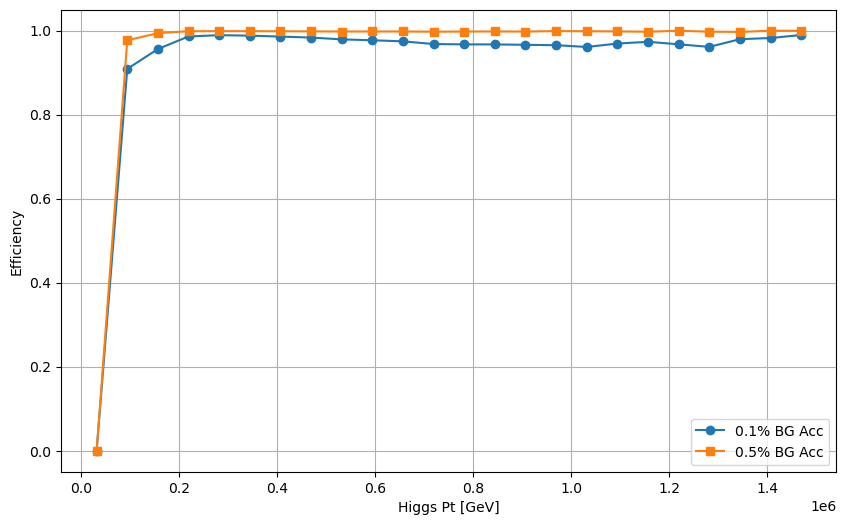

In [18]:
# ==========================================
# 9. Evaluation & Efficiency
# ==========================================
print("\nEvaluation...")
model.load_state_dict(torch.load('dnn_gnn_best.pth'))
model.eval()

# Get Test Predictions
probs_list, labels_list, weights_list = [], [], []
with torch.no_grad():
    for xb, yb, wb in test_loader:
        out = torch.sigmoid(model(xb))
        probs_list.extend(out.cpu().numpy().flatten())
        labels_list.extend(yb.cpu().numpy().flatten())
        weights_list.extend(wb.cpu().numpy().flatten())

y_true, y_score, w_test_np = np.array(labels_list), np.array(probs_list), np.array(weights_list)

# Classification Report
print(classification_report(y_true, (y_score>0.5).astype(int), sample_weight=w_test_np))

# Calculate Thresholds (0.1% and 0.5% FPR)
bg_scores = np.sort(y_score[y_true == 0])
thresh_0_1 = bg_scores[int(len(bg_scores) * 0.999)]
thresh_0_5 = bg_scores[int(len(bg_scores) * 0.995)]
print(f"Threshold 0.1% FPR: {thresh_0_1:.4f}")
print(f"Threshold 0.5% FPR: {thresh_0_5:.4f}")

# Efficiency Plot vs Higgs Pt
# We need 'Higgs_pt' which is only in Signal.
# We saved 'Higgs_pt' in df_sig before concatenation, but it might have been lost in X construction.
# Let's recover it from df_final (where non-signal events have 0, which is fine as we filter by label)
df_eval = df_final.iloc[y_test_t.cpu().numpy().flatten().argsort()] # Warning: shuffle mismatch risk
# Better: re-run inference on Signal subset specifically for plotting
sig_subset = df_final[df_final['label'] == 1].copy()
X_sig = sig_subset[feature_cols].values
X_sig_s = scaler.transform(X_sig)
X_sig_t = to_tensor(X_sig_s)

with torch.no_grad():
    sig_probs = torch.sigmoid(model(X_sig_t)).cpu().numpy().flatten()

sig_subset['score'] = sig_probs

# Plot
bins = np.linspace(300, 1500000, 25)
hist_tot, _ = np.histogram(sig_subset['Higgs_pt'], bins=bins)
hist_pass01, _ = np.histogram(sig_subset[sig_subset['score'] > thresh_0_1]['Higgs_pt'], bins=bins)
hist_pass05, _ = np.histogram(sig_subset[sig_subset['score'] > thresh_0_5]['Higgs_pt'], bins=bins)

eff01 = np.divide(hist_pass01, hist_tot, out=np.zeros_like(hist_tot, dtype=float), where=hist_tot!=0)
eff05 = np.divide(hist_pass05, hist_tot, out=np.zeros_like(hist_tot, dtype=float), where=hist_tot!=0)
ctrs = (bins[:-1]+bins[1:])/2

plt.figure(figsize=(10,6))
plt.plot(ctrs, eff01, 'o-', label='0.1% BG Acc')
plt.plot(ctrs, eff05, 's-', label='0.5% BG Acc')
plt.xlabel("Higgs Pt [GeV]")
plt.ylabel("Efficiency")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  # Set model to evaluation mode
    all_labels = []
    all_probas = []
    all_weights = [] # Collect weights for evaluation metrics if needed

    with torch.no_grad():
        for inputs, labels, weights in data_loader:
            outputs = model(inputs)
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(outputs.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) # Collect weights


    y_test = np.array(all_labels)
    y_pred_proba = np.array(all_probas)
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() # Flatten weights for scikit-learn functions


    # 1. Performance Statistics (using sample_weight)
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    # Use sample_weight in classification_report and confusion_matrix if they support it
    # Note: classification_report and confusion_matrix in older sklearn versions might not support sample_weight directly in this way.
    # If errors occur, you might need to calculate weighted metrics manually or use a library that supports this.
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve (using sample_weight)
    # roc_curve supports sample_weight
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    # 3. Signal Efficiency vs. Background Rejection (calculated from weighted FPR/TPR)
    background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency (Weighted TPR)'); plt.ylabel('Background Rejection (Weighted 1 / FPR)'); plt.title('Efficiency vs. Rejection (Weighted)'); plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix (using sample_weight)
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) # Use .1f for float annotation
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00 54112.621420145035
      Signal       1.00      1.00      1.00 54189.602417230606

    accuracy                           1.00 108302.22383737564
   macro avg       1.00      1.00      1.00 108302.22383737564
weighted avg       1.00      1.00      1.00 108302.22383737564



/tmp/ipykernel_209/631653193.py:39: RuntimeWarning: divide by zero encountered in divide
  background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)


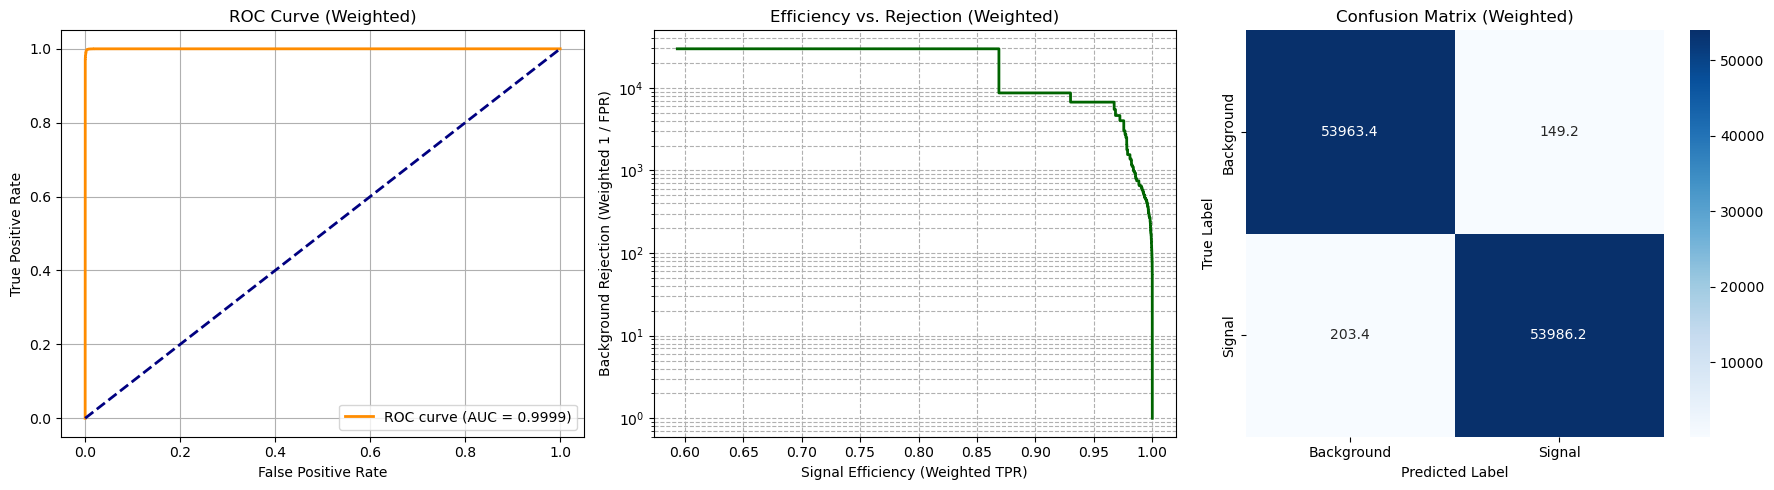

In [20]:
evaluate_model(model, test_loader, device)